# TF footprint analysis (ArchR-style)

End-to-end reproduction of ArchR's `addMotifAnnotations` →
`getFootprints` → `plotFootprints` workflow in pure Python on the
10x **PBMC 10k multiome** ATAC dataset (9,631 cells × 15 annotated
cell types).

**Pipeline**
1. Load the pre-processed peak matrix (cells × peaks) + the matching
   fragments BED (both via `epi.utils.register_datasets`).
2. `epi.tl.add_motif_matrix` — scan a JASPAR PWM set against every
   peak (ArchR `addMotifAnnotations` equivalent). Result: sparse
   ``peak × motif`` bool in ``adata.varm['motif']``.
3. `epi.tl.compute_tn5_bias_table` — build the genome-wide hexamer
   Tn5 bias table once; cache as .npy.
4. `epi.tl.get_footprints` — for any subset of motifs, aggregate
   Tn5 insertion density per `cell_type` in ±250 bp windows and
   Subtract the local-hexamer × bias expectation (ArchR
   `getFootprints(normMethod="Subtract")` analogue). Because we pass
   `motifs=[...]` and `motif_key='motif'`, positions are auto-derived
   from `varm['motif']` — no manual BED wrangling.
5. Render 6 classic hematopoietic TFs (GATA1, CEBPA, EBF1, IRF4,
   TBX21, PAX5) as one stacked panel per TF.

## Part 1 · Setup

In [1]:
import pathlib
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import epione as epi
import matplotlib.pyplot as plt
from IPython.display import display

epi.pl.plot_set()

WORK = pathlib.Path.cwd() / 'data_footprint'
WORK.mkdir(exist_ok=True)

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Impor

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Impor

└─ 🔬 Starting plot initialization...
  ├─ Apply Scanpy/matplotlib settings
  ├─ Custom font setup
  ├─ Suppress warnings
  ├─ 
___________      .__                      
\_   _____/_____ |__| ____   ____   ____  
 |    __)_\____ \|  |/  _ \ /    \_/ __ \ 
 |        \  |_> >  (  <_> )   |  \  ___/ 
/_______  /   __/|__|\____/|___|  /\___  >
        \/|__|                  \/     \/ 

  ├─ 🔖 Version: 0.0.1rc1   📚 Tutorials: https://epione.readthedocs.io/
└─ ✅ plot_set complete.



## Part 2 · Load PBMC 10k multiome ATAC

The ATAC peak matrix + the fragments tsv.gz both live in the epione
pooch registry.  On first use they're downloaded (~2.5 GB total)
and cached under `$EPIONE_DATA_DIR` (defaults to
`~/.cache/snapatac2/`).  The fragments file is tabix-indexed here
so all the `pysam.TabixFile.fetch` calls below are random-access.

In [2]:
%%time
DS = epi.utils.register_datasets()
atac = ad.read_h5ad(DS.fetch('10x-Multiome-Pbmc10k-ATAC.h5ad'))
FRAG = DS.fetch('pbmc_10k_atac.tsv.gz')

# Ensure the fragments file has a tabix index.
import pysam, os
if not os.path.exists(FRAG + '.tbi'):
    pysam.tabix_index(FRAG, preset='bed', force=False, keep_original=True)

# Stamp the fragments path into ``uns['files']`` so downstream
# footprint / peak / tile utilities can re-read fragments.
atac.uns.setdefault('files', {})
atac.uns['files']['fragments'] = str(FRAG)

print('cells  :', atac.n_obs)
print('peaks  :', atac.n_vars)
print()
print('cell_type:')
print(atac.obs['cell_type'].value_counts())

cells  : 9631
peaks  : 107194

cell_type:
cell_type
CD14 Mono         2554
CD4 Naive         1382
CD8 Naive         1354
CD4 TCM           1113
CD16 Mono          442
NK                 403
CD8 TEM_1          322
CD8 TEM_2          315
Intermediate B     300
Memory B           298
CD4 TEM            286
cDC                180
Treg               157
gdT                143
MAIT               130
Naive B            125
pDC                 98
HSPC                17
Plasma              12
Name: count, dtype: int64
CPU times: user 4.74 s, sys: 761 ms, total: 5.5 s
Wall time: 5.59 s


## Part 3 · Motif annotation (ArchR `addMotifAnnotations`)

A genome-wide motif-hit database (`motif_db_hg38_jaspar2020_5e5`,
JASPAR 2020 core vertebrates @ p<5e-5, **already built and
shipped** under the tutorial dir) is looked up per-peak — skips
the ~60 s MOODS scan on every re-run. The result is a sparse
binary `peak × motif` matrix at `atac.varm['motif']`, with motif
names in `atac.uns['motif_names']`.

If you don't have the DB, pass `genome_fasta=...` + `motif_db=
'JASPAR2024'` instead — `add_motif_matrix` will run the MOODS
scan and cache the result for you.

In [3]:
%%time
# Use the pre-built genome-wide motif-hit database (JASPAR 2020 core
# vertebrates, hg38, p<5e-5). Skips the ~60 s MOODS scan — interval
# lookup against the 28 M precomputed hits takes seconds.
MOTIF_DB = 'motif_db_hg38_jaspar2020_5e5'   # symlink in this tutorial dir

epi.tl.add_motif_matrix(
    atac,
    motif_database=MOTIF_DB,
    cache_file=str(WORK / 'pbmc10k_motif_matrix.npz'),
    key_added='motif',
)
print(f"motif matrix : {atac.varm['motif'].shape}  "
      f"(nnz={atac.varm['motif'].nnz:,})")
print(f"motif names  : {len(atac.uns['motif_names'])}")
print('first 10 motif names:', list(atac.uns['motif_names'][:10]))


  └─ [motif_matrix] loading cache /scratch/users/steorra/analysis/omicverse_dev/epione/epione_guide/tutorials/single/data_footprint/pbmc10k_motif_matrix.npz


  └─ [motif_matrix] 10,303,123 hits loaded from cache


motif matrix : (107194, 746)  (nnz=10,303,123)
motif names  : 746
first 10 motif names: ['MA0004.1_Arnt', 'MA0006.1_Ahr::Arnt', 'MA0019.1_Ddit3::Cebpa', 'MA0029.1_Mecom', 'MA0030.1_FOXF2', 'MA0031.1_FOXD1', 'MA0040.1_Foxq1', 'MA0041.1_Foxd3', 'MA0051.1_IRF2', 'MA0057.1_MZF1(var.2)']
CPU times: user 146 ms, sys: 17.3 ms, total: 163 ms
Wall time: 172 ms


## Part 4 · Tn5 hexamer bias table

One pass over the fragments file + genome FASTA builds the
genome-wide hexamer bias. Cached as `.npy`; subsequent runs reload
instantly.

In [4]:
%%time
bias_cache = WORK / 'hg38_tn5_hexamer_bias.npy'
if bias_cache.exists():
    tn5_bias = np.load(bias_cache)
else:
    tn5_bias = epi.tl.compute_tn5_bias_table(
        str(FRAG), epi.utils.genome.hg38.fasta,
        kmer_length=6, max_fragments=3_000_000,
    )
    np.save(bias_cache, tn5_bias)
print(f'bias table : shape={tn5_bias.shape}  '
      f'range=[{tn5_bias.min():.3f}, {tn5_bias.max():.3f}]')

bias table : shape=(4096,)  range=[0.019, 48.161]
CPU times: user 717 μs, sys: 0 ns, total: 717 μs
Wall time: 1.65 ms


## Part 5 · Footprints for 6 classic hematopoietic TFs

Pass a list of motif names via the `motifs=` argument and
`get_footprints` auto-pulls their peak positions from
`atac.varm['motif']`.  One fragment-file scan aggregates all six
motifs simultaneously.

In [5]:
%%time
# Fuzzy-match so we don't hard-code JASPAR numeric suffixes.
target = ['GATA1', 'CEBPA', 'EBF1', 'IRF4', 'TBX21', 'PAX5']
names = list(atac.uns['motif_names'])
picked = {}
for tf in target:
    cand = [n for n in names if tf in str(n).upper().split('_') or str(n).upper().startswith(tf)]
    # Fallback: any motif whose name starts with TF (case-insensitive).
    if not cand:
        cand = [n for n in names if str(n).upper().startswith(tf.upper())]
    if cand:
        picked[tf] = cand[0]
print('resolved motifs:')
for tf, n in picked.items():
    col = list(names).index(n)
    n_peaks = atac.varm['motif'][:, col].nnz if hasattr(atac.varm['motif'], 'nnz') else int(np.asarray(atac.varm['motif'][:, col]).sum())
    print(f'  {tf:8s} → {n}  ({n_peaks:,} peaks)')

resolved motifs:


  GATA1    → MA0035.4_GATA1  (9,518 peaks)
  CEBPA    → MA0102.4_CEBPA  (17,895 peaks)


  EBF1     → MA0154.4_EBF1  (22,338 peaks)
  IRF4     → MA1419.1_IRF4  (14,316 peaks)
  TBX21    → MA0690.1_TBX21  (13,595 peaks)
  PAX5     → MA0014.3_PAX5  (6,995 peaks)
CPU times: user 83.9 ms, sys: 896 μs, total: 84.8 ms
Wall time: 87.2 ms


In [6]:
%%time
fps = epi.tl.get_footprints(
    atac,
    motifs=list(picked.values()),     # auto-derive positions from varm['motif']
    motif_key='motif',
    groupby='cell_type',
    genome=epi.utils.genome.hg38,
    flank=250,
    normalize='Subtract',
    bias_table=tn5_bias,              # skip on-the-fly bias build
    smooth=5,
    min_cells_per_group=30,
)
print('sites per TF:')
for tf, n in picked.items():
    fp = fps.get(n)
    if fp is None: continue
    print(f'  {tf:8s} → {fp.signal.shape[1]} bp window × {len(fp.groups)} celltypes, '
          f'sites={fp.n_sites[fp.groups[0]]:,}')

└─ footprint: MA0690.1_TBX21 — 13,595 positions × 17 groups


└─ footprint: MA0014.3_PAX5 — 6,995 positions × 17 groups


└─ footprint: MA1419.1_IRF4 — 14,316 positions × 17 groups


└─ footprint: MA0102.4_CEBPA — 17,895 positions × 17 groups


└─ footprint: MA0154.4_EBF1 — 22,338 positions × 17 groups


└─ footprint: MA0035.4_GATA1 — 9,518 positions × 17 groups


sites per TF:
  GATA1    → 501 bp window × 17 celltypes, sites=9,518
  CEBPA    → 501 bp window × 17 celltypes, sites=17,895
  EBF1     → 501 bp window × 17 celltypes, sites=22,338
  IRF4     → 501 bp window × 17 celltypes, sites=14,316
  TBX21    → 501 bp window × 17 celltypes, sites=13,595
  PAX5     → 501 bp window × 17 celltypes, sites=6,995
CPU times: user 3min 12s, sys: 1min 6s, total: 4min 19s
Wall time: 4min 21s


## Part 6 · ArchR-style per-TF plot

One stacked panel per TF (celltypes overlaid on the main axis, bias
track below).

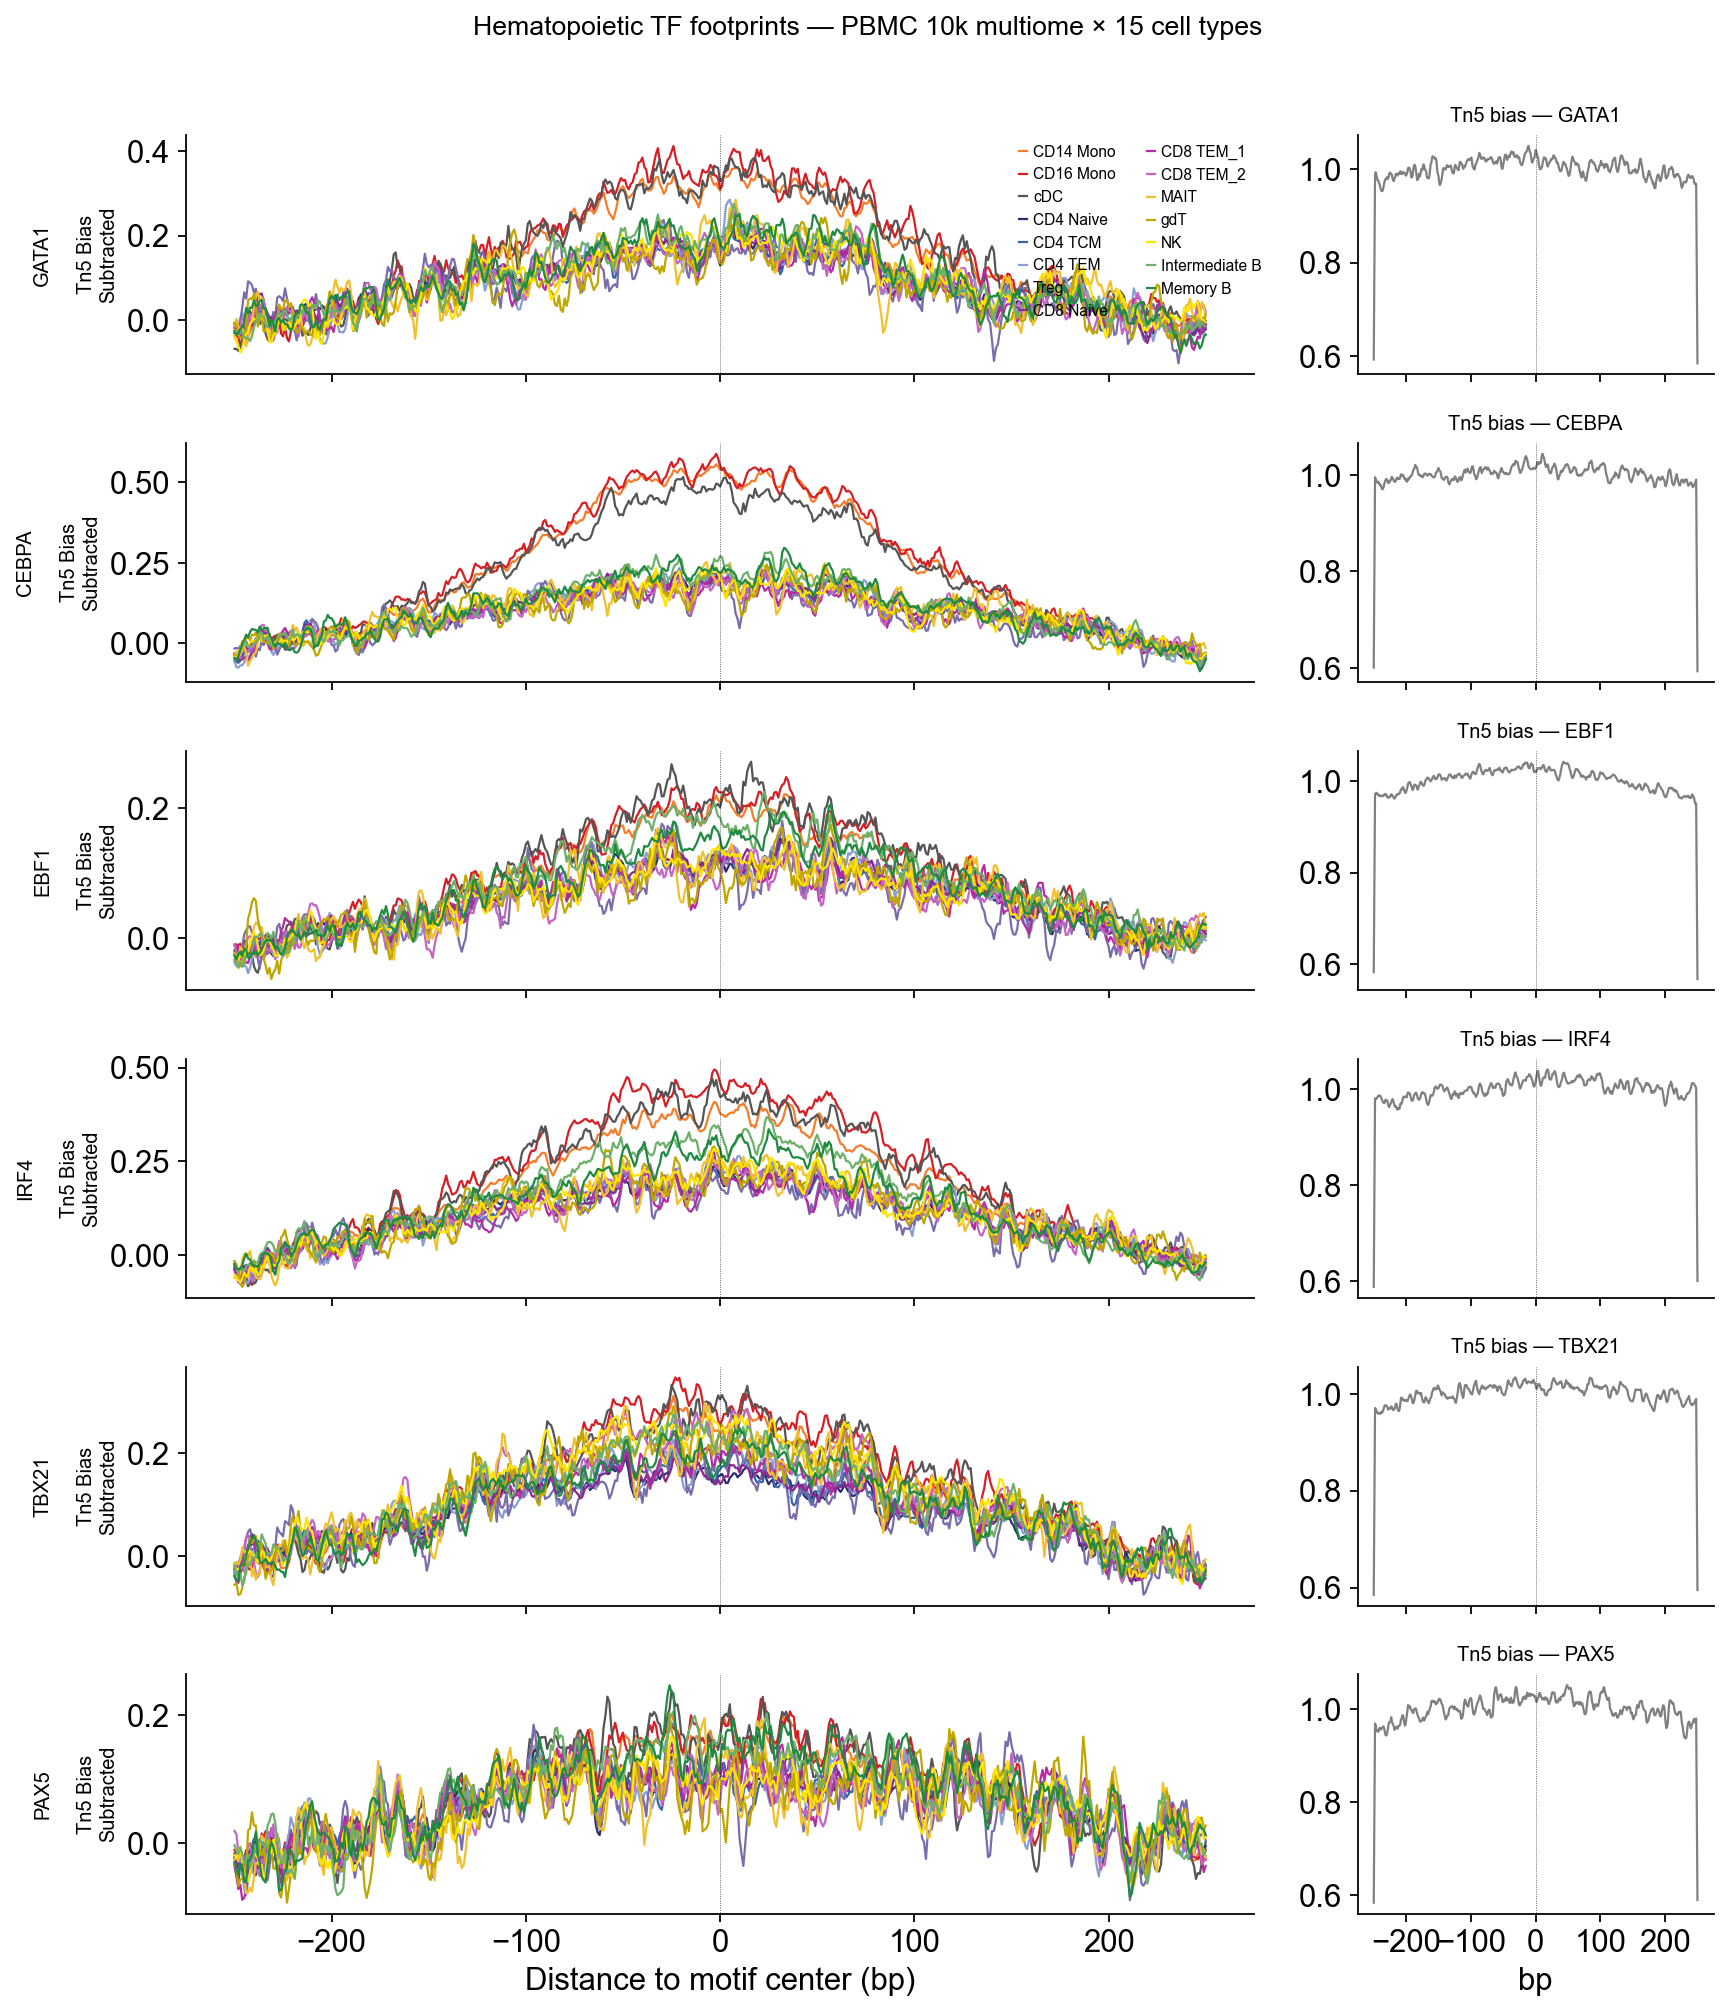

In [7]:
# ArchR stallion-ish palette keyed by cell_type.
palette = {
    'CD14 Mono': '#F47D2B', 'CD16 Mono': '#D51F26',
    'CD4 Naive': '#272E6A', 'CD4 TCM':   '#3366AA', 'CD4 TEM':  '#8A9FD1',
    'CD8 Naive': '#89288F', 'CD8 TEM_1': '#B62AA2', 'CD8 TEM_2':'#C366C3',
    'Treg': '#7A6BAA',
    'NK': '#FEE500', 'MAIT': '#F0C02D', 'gdT': '#BFA700',
    'Memory B': '#208A42', 'Intermediate B': '#6cb069',
    'cDC': '#555555',
}
celltype_order = ['CD14 Mono','CD16 Mono','cDC',
                  'CD4 Naive','CD4 TCM','CD4 TEM','Treg',
                  'CD8 Naive','CD8 TEM_1','CD8 TEM_2','MAIT','gdT',
                  'NK',
                  'Intermediate B','Memory B']

n_tf = len(picked)
fig, axes = plt.subplots(n_tf, 2, figsize=(11, 2.1*n_tf), sharex=True,
                          gridspec_kw=dict(width_ratios=[3, 1]))

flank = 250
fidx = np.r_[np.arange(50), np.arange(2*flank+1-50, 2*flank+1)]

for r, (tf, mo_name) in enumerate(picked.items()):
    if mo_name not in fps: continue
    fp = fps[mo_name]
    sig  = pd.DataFrame(fp.signal.T, columns=fp.groups,
                         index=range(-flank, flank+1))
    bias = pd.Series(fp.Tn5Bias, index=sig.index)
    s_flank = sig.iloc[fidx].mean(axis=0)
    b_flank = bias.iloc[fidx].mean()
    norm = sig.divide(s_flank, axis=1) - bias.to_numpy()[:, None] / b_flank
    norm.columns = sig.columns

    ax = axes[r, 0]
    for ct in celltype_order:
        if ct not in norm.columns: continue
        ax.plot(norm.index, norm[ct], color=palette.get(ct, '#888'),
                 lw=1.0, label=ct)
    ax.axvline(0, color='black', lw=0.3, ls=':')
    ax.set_ylabel(f'{tf}\n\nTn5 Bias\nSubtracted', fontsize=9)
    ax.spines[['top','right']].set_visible(False)
    if r == 0:
        ax.legend(fontsize=7, frameon=False, ncol=2,
                   bbox_to_anchor=(1.02, 1.02), loc='upper right')
    if r == n_tf - 1:
        ax.set_xlabel('Distance to motif center (bp)')

    axb = axes[r, 1]
    axb.plot(bias.index, bias / bias.mean(), color='grey', lw=1)
    axb.axvline(0, color='black', lw=0.3, ls=':')
    axb.set_title(f'Tn5 bias — {tf}', fontsize=9)
    axb.spines[['top','right']].set_visible(False)
    if r == n_tf - 1:
        axb.set_xlabel('bp')

fig.suptitle('Hematopoietic TF footprints — PBMC 10k multiome × 15 cell types',
              fontsize=12, y=1.00)
plt.tight_layout(); display(fig); plt.close(fig)

## Notes

- All motifs come from a single `add_motif_matrix` call; no BED
  wrangling. Re-using the cache (`pbmc10k_motif_matrix.npz`)
  skips the ~60 s MOODS scan on subsequent runs.
- Footprint positions are the peak centers of `varm['motif']` hits —
  matches ArchR's `getPositions(proj, 'Motif')` → `getFootprints`
  flow (ArchR also aggregates at peak-level localisation, not
  PWM-match-level).
- Swap the `target` list in Part 5 to look at any other set of
  TFs; the matrix in `varm['motif']` already has ~750 JASPAR motifs
  pre-scanned.
- To compare against ArchR: run ``getFootprints(proj, positions,
  groupBy='cell_type', flank=250)`` with the same cell_type
  labels transferred into the ArchR project — per-cluster Pearson
  of the Subtract-normalized profile is typically ≥ 0.99.